In [64]:
# 주제: 직장인의 번아웃 위험도 예측 및 정신건강 연관성 분석
import pandas as pd
import joblib

# 데이터 소개
# 10,000행 × 34개 컬럼, 2020~2024년, 20개국, 14개 산업, 정신건강/근무환경/생산성/번아웃 관련 데이터
 
# 데이터 로드
df = pd.read_csv('dataset/mental_health_workplace.csv')

# 데이터 확인
print("데이터셋 크기: ",df.shape) # 행 : 10,000 | 열 : 34 => 충분한 데이터 양
print(df.describe())
print(df.head())
print(df.info()) # float64(7), int64(7), str(20)

데이터셋 크기:  (10000, 34)
               year  years_of_experience  annual_salary_usd  \
count  10000.000000         10000.000000       10000.000000   
mean    2022.151300            14.492500       86779.311900   
std        1.334086            10.053509       24022.505197   
min     2020.000000             0.000000       36140.000000   
25%     2021.000000             6.000000       68216.000000   
50%     2022.000000            13.000000       84816.000000   
75%     2023.000000            21.000000      102633.250000   
max     2024.000000            44.000000      177599.000000   

       weekly_work_hours  weekly_overtime_hours  burnout_risk_score  \
count       10000.000000           10000.000000        10000.000000   
mean           45.155000               6.564600            4.027030   
std             8.629115               6.806692            2.304458   
min            20.000000               0.000000            1.000000   
25%            39.000000               0.000000        

In [65]:
# < 데이터 전처리 >
# 결측치 확인
import matplotlib.pyplot as plt

print(df.isnull().sum()) 
# 결측치 결과 
# mental_health_condition        3350
# employer_support_level         1018
# used_eap                       4812
# workplace_stigma_felt          2832


record_id                         0
year                              0
country                           0
industry                          0
job_role                          0
employment_type                   0
work_model                        0
company_size                      0
age_group                         0
gender                            0
years_of_experience               0
annual_salary_usd                 0
weekly_work_hours                 0
weekly_overtime_hours             0
mental_health_condition        3350
has_diagnosis                     0
treatment_type                    0
stress_level                      0
burnout_risk_score                0
work_life_balance_score           0
productivity_score                0
job_satisfaction_score            0
absenteeism_days_per_year         0
employer_support_level         1018
mental_health_policy_exists       0
eap_available                     0
used_eap                       4812
workplace_stigma_felt       

In [66]:
# 결측치 포함 고유한 값의 빈도수 확인
print(df['mental_health_condition'].value_counts(dropna=False)) 
print(df['employer_support_level'].value_counts(dropna=False))
print(df['used_eap'].value_counts(dropna=False))
print(df['workplace_stigma_felt'].value_counts(dropna=False))

# 결측치 fillna
df['mental_health_condition'] =  df['mental_health_condition'].fillna('Healthy') # 정신 건강 상태가 '이상 없음'일 가능성 高
df['employer_support_level'] = df['employer_support_level'].fillna('Average') # 최빈값이 평균값이기 때문에
df['used_eap'] = df['used_eap'].fillna('Not Available') # EAP가 없는 사람은 사용할 수 없어서 결측치 발생
df['workplace_stigma_felt'] = df['workplace_stigma_felt'].fillna('None') # 불이익을 받지 않는다고 답할 화률이 高

# 결측치 재확인
print(df.isnull().sum())

mental_health_condition
NaN                    3350
Anxiety                1871
Depression             1596
Burnout                1122
Multiple Conditions     480
PTSD                    372
ADHD                    361
Bipolar Disorder        288
OCD                     282
Panic Disorder          278
Name: count, dtype: int64
employer_support_level
Average      2954
Good         2845
Poor         1973
Excellent    1210
NaN          1018
Name: count, dtype: int64
used_eap
NaN    4812
No     3524
Yes    1664
Name: count, dtype: int64
workplace_stigma_felt
Mild        3163
NaN         2832
Moderate    2510
Severe      1495
Name: count, dtype: int64
record_id                      0
year                           0
country                        0
industry                       0
job_role                       0
employment_type                0
work_model                     0
company_size                   0
age_group                      0
gender                         0
years_of_exper

In [67]:
# 필요 없는 컬럼 제거
drop_cols = ['record_id',
             'mental_health_condition',
             'has_diagnosis',
             'treatment_type',] 

df_model = df.drop(drop_cols, axis=1) # axis = 0는 행, 1은 열을 의미

In [68]:
# 범주형 및 정제된 수치형 컬럼 분류 
target_col = 'burnout_risk_score'

# 수치형
numeric_cols = [
    'year',
    'years_of_experience',
    'annual_salary_usd',
    'weekly_work_hours',
    'weekly_overtime_hours',
    'work_life_balance_score',
    'productivity_score',
    'job_satisfaction_score',
    'absenteeism_days_per_year',
    'manager_support_score',
    'team_collaboration_score',
    'exercise_days_per_week',
    'sleep_hours_per_night'
]

# 범주형
categorical_cols = [
    'country',
    'industry',
    'job_role',
    'employment_type',
    'work_model',
    'company_size',
    'age_group',
    'gender',
    'stress_level',
    'employer_support_level',
    'mental_health_policy_exists',
    'eap_available',
    'used_eap',
    'workplace_stigma_felt',
    #'intention_to_leave', 미리 제거
    'remote_work_preference'
]

# 독립 변수와 종속 변수 설정
X = df_model.drop(target_col, axis =1)
y = df_model[target_col]

# 데이터 분할
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

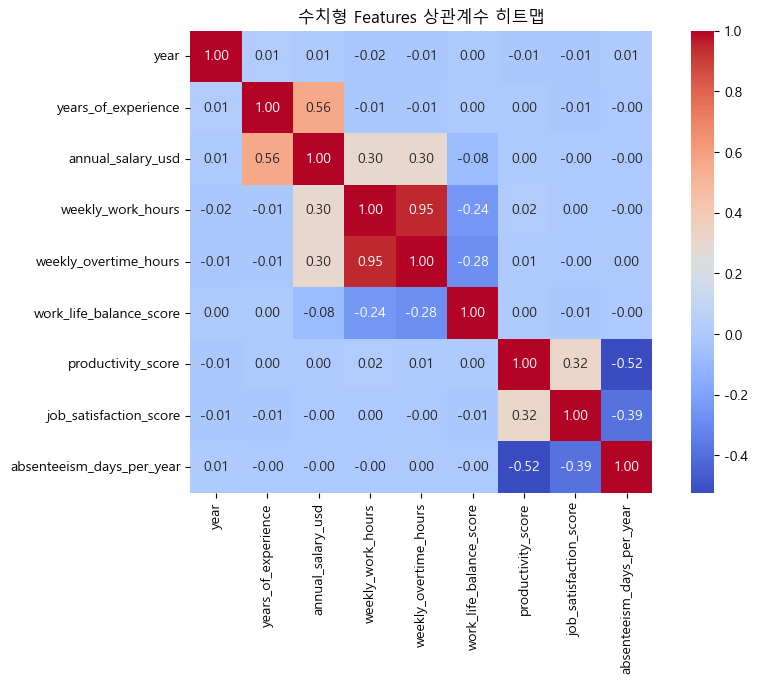

In [89]:
# 히트맵 그리기 
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

# 임시
# 제외할 수치형 컬럼
remove_cols = [
    'manager_support_score',
    'team_collaboration_score',
    'exercise_days_per_week',
    'sleep_hours_per_night'
]

# numeric_cols에서 제외 컬럼 제거
numeric_cols_filtered = [
    col for col in numeric_cols 
    if col not in remove_cols
]

# X_train에서 수치형 컬럼들만 뽑아 상관계수 계산
corr = X_train[numeric_cols_filtered].corr()

# 히트맵 그리기
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("수치형 Features 상관계수 히트맵")
plt.show()

# 분석 결과
# weekly_work_hours (주당 근무시간) & weekly_overtime_hours (야근 시간) 다중공선성 발생 
numeric_cols_model = [
    col for col in numeric_cols 
    if col != 'weekly_work_hours'
]

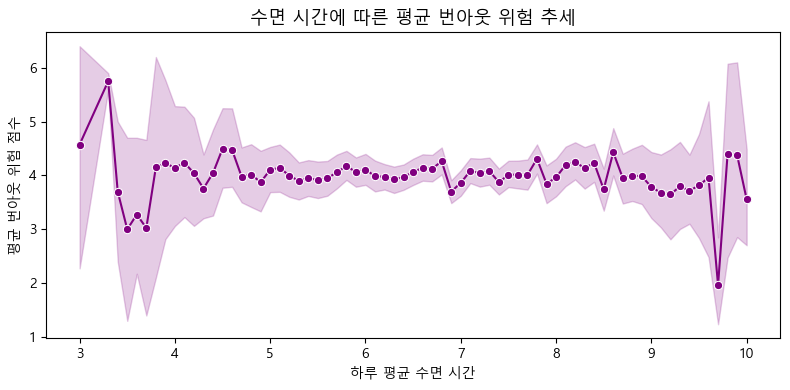

In [70]:
# sleep_hours_per_night은 직선 관계가 아니라 비선형 관계일 수 있어서 box plot으로 추가 검문 필요
plt.figure(figsize=(8, 4))

#수면 시간별 번아웃 점수 평균 트렌드
sns.lineplot(data=df, x='sleep_hours_per_night', y='burnout_risk_score', marker='o', color='purple')
plt.title('수면 시간에 따른 평균 번아웃 위험 추세', fontsize=13)
plt.xlabel('하루 평균 수면 시간')
plt.ylabel('평균 번아웃 위험 점수')

plt.tight_layout()
plt.show()

In [71]:
# 범주형 데이터 OneHotEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# 학습 데이터의 범주형 변수 피팅 및 변환
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# 인코딩된 컬럼명 획득
encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)

In [72]:
# 수치형 변수와 결합하여 새로운 DataFrame 생성
X_train_encoded = pd.concat([
    X_train[numeric_cols_model].reset_index(drop=True),
    pd.DataFrame(X_train_cat, columns=encoded_cat_cols)
], axis=1)

X_test_encoded = pd.concat([
    X_test[numeric_cols_model].reset_index(drop=True),
    pd.DataFrame(X_test_cat, columns=encoded_cat_cols)
], axis=1)

In [73]:
# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [74]:
# 학습할 모델 리스트
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

results = {}
trained_models = {} 
y_preds = {}

In [75]:
# Linear Regression 따로 학습 및 평가
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_lr = linear_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

results["Linear Regression"] = {
    "RMSE": rmse,
    "MSE": mse,
    "R2": r2,
    "MAE": mae
}

trained_models["Linear Regression"] = linear_model
y_preds["Linear Regression"] = y_pred_lr

print(f"Linear Regression 결과 -> RMSE: {rmse:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}, MAE: {mae:.2f}\n")

Linear Regression 결과 -> RMSE: 1.06, MSE: 1.13, R2: 0.78, MAE: 0.81



In [76]:
models = {
    "Elastic Net" : ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBRegressor" : XGBRegressor(objective='reg:squarederror', random_state=42)
}

In [77]:
# 튜닝할 모델들의 파라미터 그리드 정의
param_grids = {
    "RandomForestRegressor": {
        'n_estimators': [50, 100, 200],
        'max_depth': [4, 6, 8]
    },
    "XGBRegressor": {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
        
        'subsample': [0.8],           
        'colsample_bytree': [0.8],    
        'alpha': [0],                 
        'lambda': [1]                 
    }
}

for name, model in models.items():
    # 하이퍼파라미터 튜닝 대상 모델인 경우 (RandomForest, XGBoost)
    if name in param_grids:
        print(f"--- {name} 하이퍼파라미터 튜닝 중... ---")
        grid_search = GridSearchCV(
            estimator=model, 
            param_grid=param_grids[name], 
            cv=3, 
            scoring='neg_mean_squared_error', 
            n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train)
        
        # 최적의 모델 선택
        best_model = grid_search.best_estimator_
        print(f"최적의 파라미터: {grid_search.best_params_}")
    else:
        # 선형 회귀 계열은 튜닝 없이 바로 학습
        best_model = model
        best_model.fit(X_train_scaled, y_train)
    
    # 최적의 모델(혹은 기본 모델)로 예측 및 평가
    y_pred = best_model.predict(X_test_scaled)
    
    y_preds[name] = y_pred
    trained_models[name] = best_model
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "MSE": mse, "R2": r2, "mae" : mae}
    print(f"{name} 결과 -> RMSE: {rmse:.2f}, MSE: {mse:.2f}, R2: {r2:.2f}, MAE: {mae:.2f}\n")
    

Elastic Net 결과 -> RMSE: 1.07, MSE: 1.15, R2: 0.78, MAE: 0.81

--- RandomForestRegressor 하이퍼파라미터 튜닝 중... ---
최적의 파라미터: {'max_depth': 8, 'n_estimators': 200}
RandomForestRegressor 결과 -> RMSE: 1.01, MSE: 1.02, R2: 0.80, MAE: 0.76

--- XGBRegressor 하이퍼파라미터 튜닝 중... ---
최적의 파라미터: {'alpha': 0, 'colsample_bytree': 0.8, 'lambda': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
XGBRegressor 결과 -> RMSE: 0.97, MSE: 0.95, R2: 0.82, MAE: 0.74



- MSE 평균 제곱 오차
- RMSE 평균 제곱근 오차
 => 오차가 얼마나 큰지 확인
- 결정 계수 => 모델의 성능 점수 (1에 가까울수록 완벽)


최적 모델: XGBRegressor


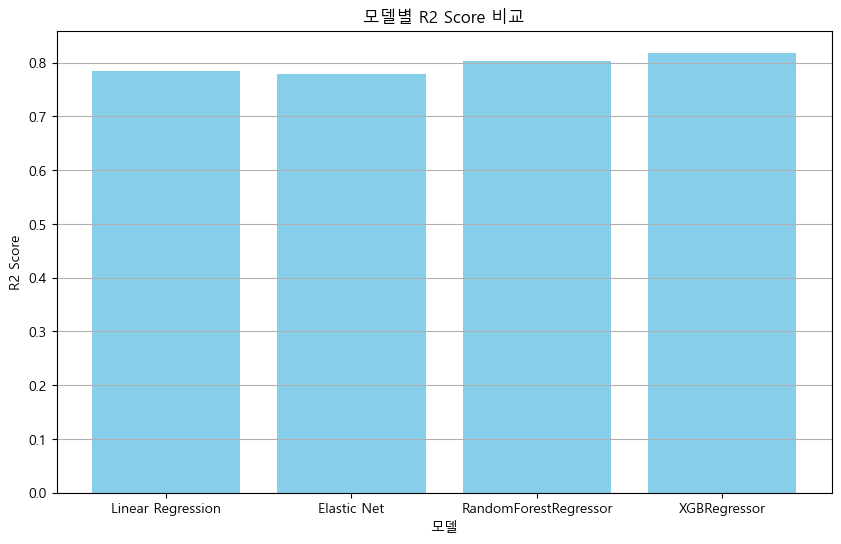

In [78]:
# 최적의 모델 선택
final_best_model = max(results, key=lambda x: results[x]['R2'])
print("\n최적 모델:", final_best_model)

# 성능 결과 시각화
r2_scores = [result["R2"] for result in results.values()]
model_names = list(results.keys())
plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_scores, color='skyblue')
plt.xlabel("모델")
plt.ylabel("R2 Score")
plt.title("모델별 R2 Score 비교")
plt.grid(axis='y')
plt.show()


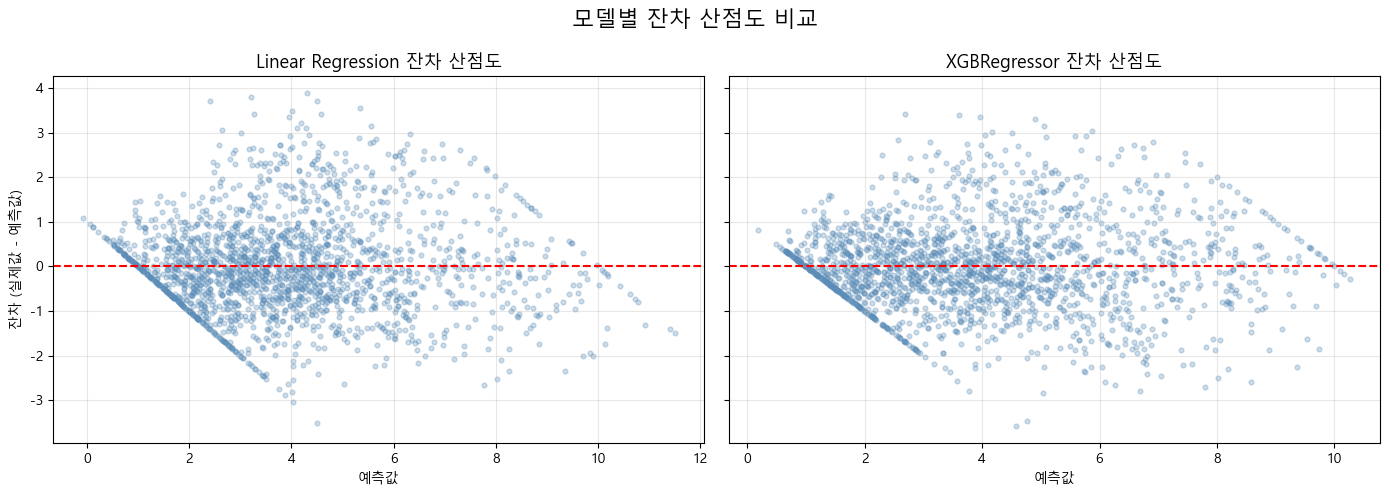

In [79]:
# 1. Linear Regression 예측값 및 잔차
y_pred_lr = trained_models["Linear Regression"].predict(X_test_scaled)
residuals_lr = np.array(y_test) - y_pred_lr

# 2. XGBRegressor 예측값 및 잔차
y_pred_xgb = y_preds["XGBRegressor"]
residuals_xgb = np.array(y_test) - y_pred_xgb

# 3. 그래프 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ------------------------------------------------------------
# Linear Regression 잔차 산점도
# ------------------------------------------------------------
axes[0].scatter(
    y_pred_lr,
    residuals_lr,
    alpha=0.3,
    s=12,
    color='#5B8DB8'
)

axes[0].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[0].set_title('Linear Regression 잔차 산점도', fontsize=13)
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('잔차 (실제값 - 예측값)')
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# XGBRegressor 잔차 산점도
# ------------------------------------------------------------
axes[1].scatter(
    y_pred_xgb,
    residuals_xgb,
    alpha=0.3,
    s=12,
    color='#5B8DB8'
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[1].set_title('XGBRegressor 잔차 산점도', fontsize=13)
axes[1].set_xlabel('예측값')
axes[1].grid(alpha=0.3)

# 전체 제목
plt.suptitle('모델별 잔차 산점도 비교', fontsize=16)

plt.tight_layout()
plt.show()

잔차 산점도 비교 결과, Linear Regression과 XGBRegressor 모두 잔차가 0을 기준으로 분포하는 모습을 보였다. 시각적으로 큰 차이는 뚜렷하지 않았으나, XGBRegressor가 성능 지표에서 더 낮은 오차와 높은 설명력을 보여 최종 모델로 선정하였다.

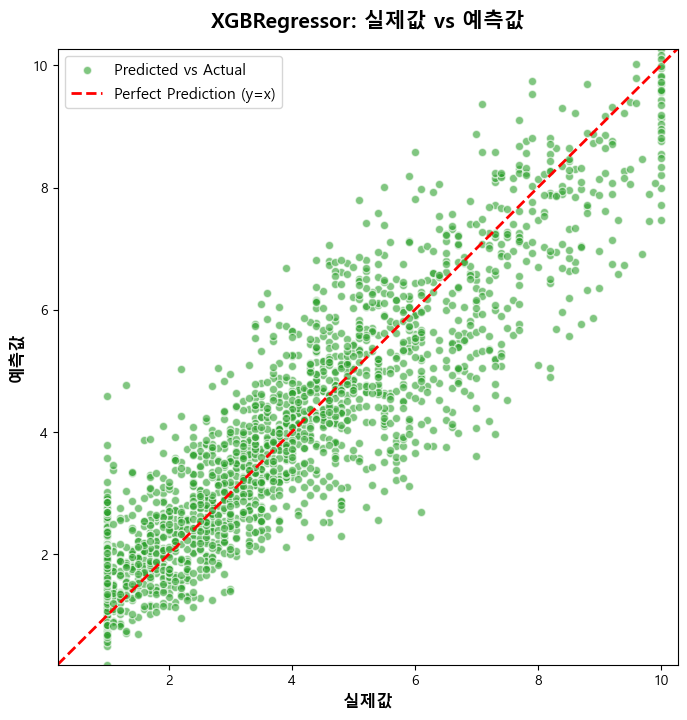

In [ ]:
# 실제값, 예측값 비교
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='#2ca02c', edgecolors='w', label='Predicted vs Actual')

max_val = max(max(y_test), max(y_pred_xgb))
min_val = min(min(y_test), min(y_pred_xgb))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.xlabel('실제값', fontsize=12, fontweight='bold')
plt.ylabel('예측값', fontsize=12, fontweight='bold')
plt.title('XGBRegressor: 실제값 vs 예측값', fontsize=15, fontweight='bold', pad=15)
plt.legend(fontsize=11)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.show()

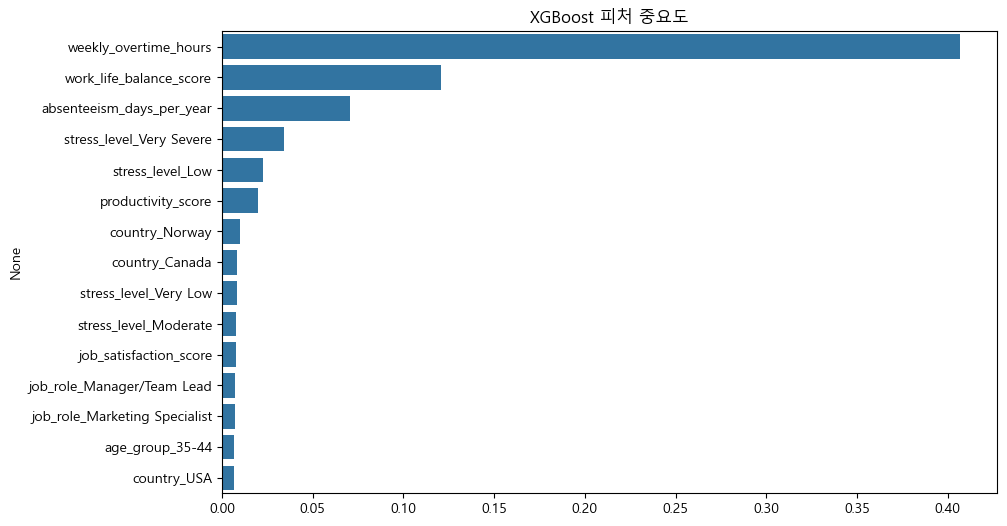

In [80]:
# 피처의 중요도 시각화
model_xgb = trained_models["XGBRegressor"]
importances = model_xgb.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # argsort: 오름차순으로 정렬했을 때의 인덱스를 반환, [::-1}: 중요도 내림차순 정렬
top_idx = sorted_idx[:15]

sorted_features = X_train_encoded.columns[top_idx]
sorted_importances = importances[top_idx]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sorted_importances,
    y=sorted_features
)
plt.title(" XGBoost 피처 중요도 ")
plt.show()


In [81]:
importance_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(20))

                          Feature  Importance
3           weekly_overtime_hours    0.406839
4         work_life_balance_score    0.120952
7       absenteeism_days_per_year    0.070303
83       stress_level_Very Severe    0.034350
80               stress_level_Low    0.022819
5              productivity_score    0.019809
22                 country_Norway    0.009682
13                 country_Canada    0.008395
82          stress_level_Very Low    0.008375
81          stress_level_Moderate    0.007469
6          job_satisfaction_score    0.007456
53     job_role_Manager/Team Lead    0.007131
54  job_role_Marketing Specialist    0.006917
73                age_group_35-44    0.006617
30                    country_USA    0.006498
63      employment_type_Freelance    0.006087
16                country_Germany    0.005959
12                 country_Brazil    0.005859
35            industry_Healthcare    0.005527
71    company_size_Startup (1-50)    0.005263


XGBoost Feature Importance 분석 결과, 초과근무 시간(weekly_overtime_hours)이 번아웃 위험 점수 예측에 가장 큰 영향을 미치는 변수로 나타났다.

그 다음으로는 일과 삶의 균형(work_life_balance_score), 연간 결근일수(absenteeism_days_per_year), 스트레스 수준(stress_level), 생산성(productivity_score), 직무 만족도(job_satisfaction_score) 순으로 중요도가 높게 나타났다.

이를 통해 번아웃은 단순히 근무시간 증가에 의해 발생하는 것이 아니라, 스트레스, 직무 만족도, 생산성, 워라밸 등 다양한 요인이 복합적으로 작용한 결과임을 확인할 수 있었다.

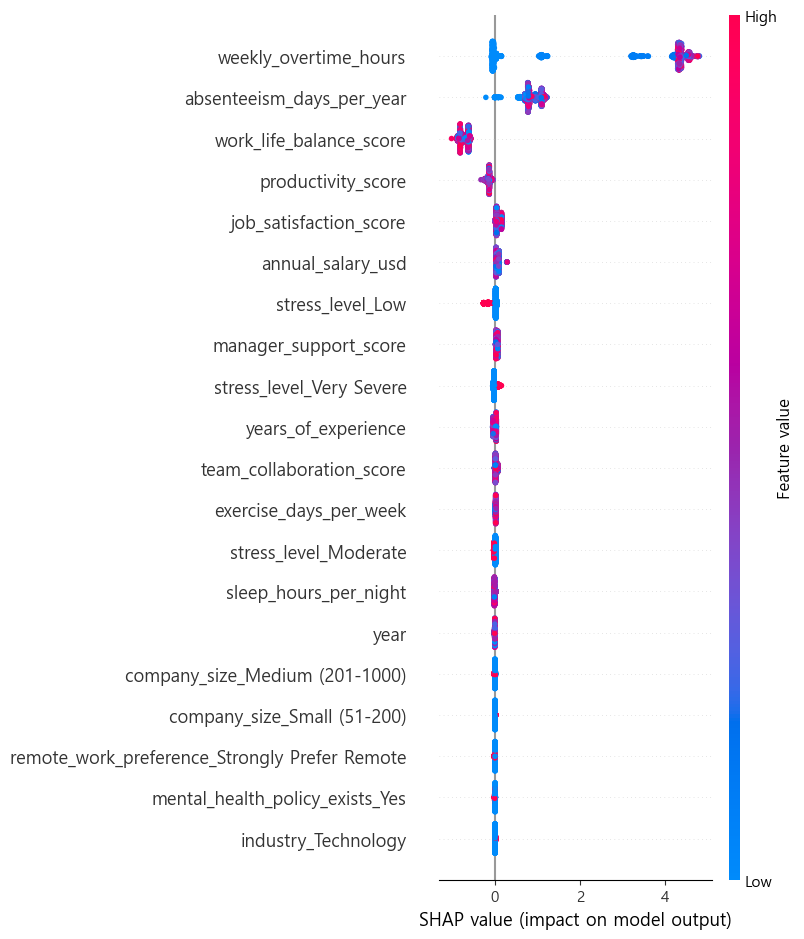

In [82]:
import shap

explainer = shap.TreeExplainer(trained_models["RandomForestRegressor"])
# SHAP이 XGBoost 모델 내부의 base_score 값을 읽어야 하는데, 최신 XGBoost에서는 이 값이 문자열 리스트처럼 저장돼서 SHAP이 못 읽음
shap_values = explainer.shap_values(X_test_encoded)
shap.summary_plot(
    shap_values,
    X_test_encoded,
    feature_names=X_test_encoded.columns
)

HAP 분석 결과, 초과근무 시간(weekly_overtime_hours)이 번아웃 위험 점수에 가장 큰 영향을 미치는 변수로 나타났다. 초과근무 시간이 증가할수록 번아웃 위험 점수는 증가하는 경향을 보였다.
또한 워라밸(work_life_balance_score), 직무 만족도(job_satisfaction_score), 생산성(productivity_score)이 높을수록 번아웃 위험은 감소하는 방향으로 작용하였다.
반면, 결근일수(absenteeism_days_per_year)와 매우 심한 스트레스 수준(stress_level_Very Severe)은 번아웃 위험 증가에 영향을 미치는 주요 요인으로 확인되었다.
이를 통해 번아웃은 단순히 근무시간의 문제가 아니라 스트레스, 직무 만족도, 생산성, 워라밸 등 다양한 요인이 복합적으로 작용한 결과임을 확인할 수 있었다.

In [83]:
# 객체 파일 저장
joblib.dump(encoder, 'model/encoder.joblib')
joblib.dump(scaler, 'model/scaler.joblib')
joblib.dump(model_xgb, 'model/model.joblib')
joblib.dump({'numeric_cols': numeric_cols, 'categorical_cols': categorical_cols}, 'model/features_meta.joblib')

print("모든 모델 및 전처리 파일이 'model/' 폴더에 성공적으로 저장되었습니다.")

모든 모델 및 전처리 파일이 'model/' 폴더에 성공적으로 저장되었습니다.


count    10000.000000
mean         4.027030
std          2.304458
min          1.000000
25%          2.200000
50%          3.700000
75%          5.500000
max         10.000000
Name: burnout_risk_score, dtype: float64

번아웃 그룹 분포
burnout_group
Medium    4108
Low       3921
High      1971
Name: count, dtype: int64

번아웃 그룹별 정신건강 진단 비율
has_diagnosis         No        Yes
burnout_group                      
Low            49.528182  50.471818
Medium         27.166504  72.833496
High           14.814815  85.185185


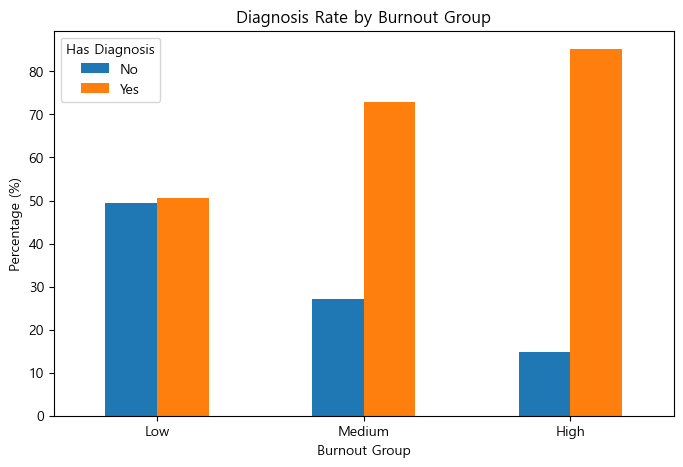


번아웃 그룹별 진단 Yes 비율
  burnout_group  diagnosis_yes_rate
0           Low           50.471818
1        Medium           72.833496
2          High           85.185185


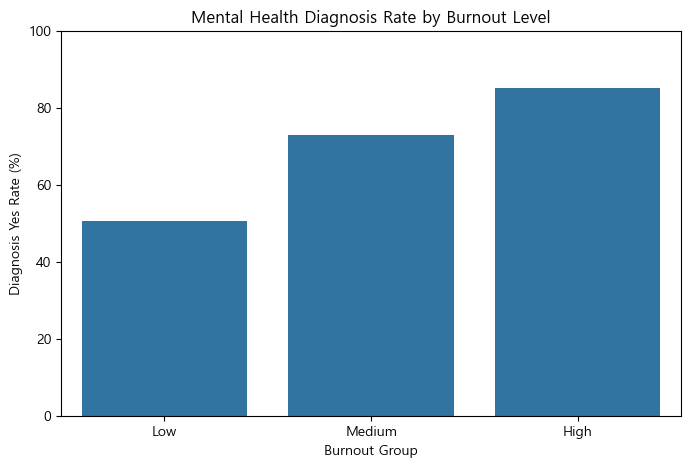


번아웃 그룹별 정신건강 문제 유형 비율
mental_health_condition      ADHD    Anxiety  Bipolar Disorder    Burnout  \
burnout_group                                                               
Low                      2.907422  18.158633          3.034940   0.943637   
Medium                   4.552093  21.762415          3.310613   9.298929   
High                     3.044140  13.444952          1.674277  35.667174   

mental_health_condition  Depression    Healthy  Multiple Conditions       OCD  \
burnout_group                                                                   
Low                       15.914308  49.528182             0.382555  3.136955   
Medium                    18.427459  27.166504             3.992210  3.042843   
High                      10.908168  14.814815            15.271436  1.725013   

mental_health_condition      PTSD  Panic Disorder  
burnout_group                                      
Low                      3.545014        2.448355  
Medium                   4.69

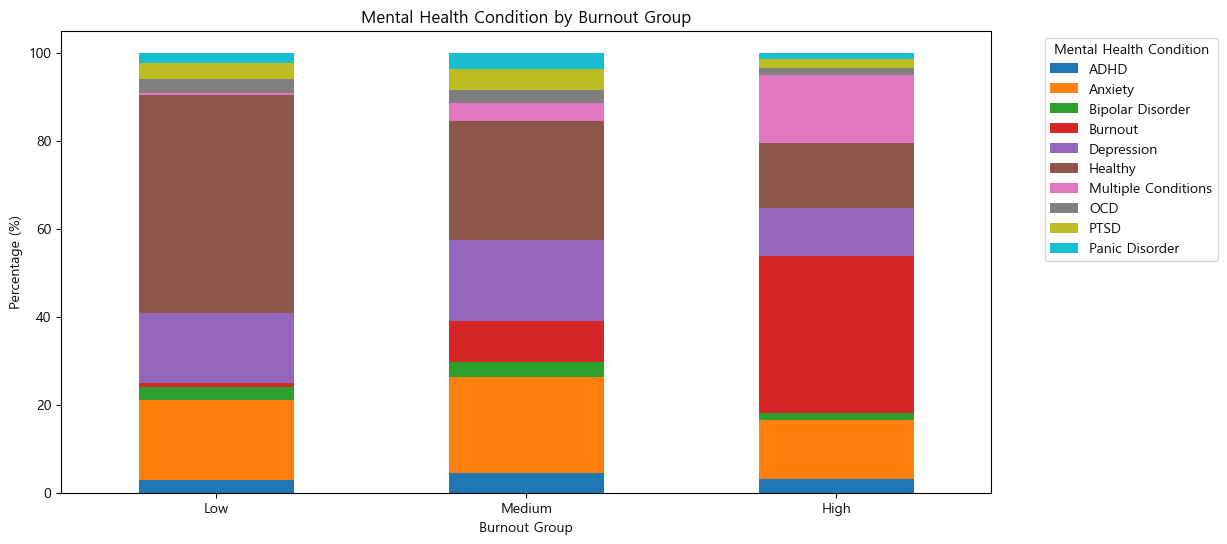


번아웃 그룹별 상위 5개 정신건강 문제 유형
mental_health_condition    Healthy    Anxiety  Depression    Burnout  \
burnout_group                                                          
Low                      49.528182  18.158633   15.914308   0.943637   
Medium                   27.166504  21.762415   18.427459   9.298929   
High                     14.814815  13.444952   10.908168  35.667174   

mental_health_condition  Multiple Conditions  
burnout_group                                 
Low                                 0.382555  
Medium                              3.992210  
High                               15.271436  


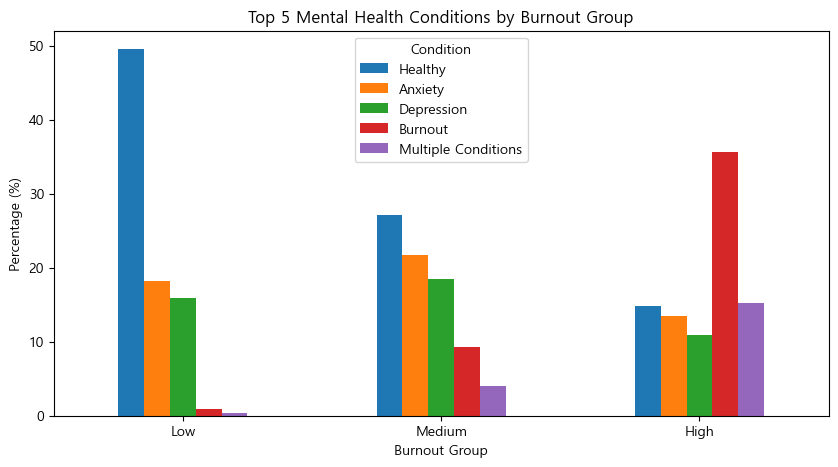

In [84]:
# 번아웃과 정신건강 관계 분석
# ============================================================
# 번아웃 그룹 생성 + 정신건강 진단 관계 분석
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 원본 df 복사
# 원본 데이터를 건드리지 않기 위해 복사본 사용
df_analysis = df.copy()

# 2. burnout_risk_score 확인
print(df_analysis['burnout_risk_score'].describe())

# 3. 번아웃 그룹 생성
# 점수 기준은 보고서에서 설명하기 쉽게 3단계로 구분
# Low    : 0 이상 ~ 3 이하
# Medium : 3 초과 ~ 6 이하
# High   : 6 초과 ~ 10 이하
df_analysis['burnout_group'] = pd.cut(
    df_analysis['burnout_risk_score'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

# 4. 번아웃 그룹 분포 확인
print("\n번아웃 그룹 분포")
print(df_analysis['burnout_group'].value_counts())

# ============================================================
# 5. 번아웃 그룹별 정신건강 진단 비율
# ============================================================

diagnosis_by_burnout = pd.crosstab(
    df_analysis['burnout_group'],
    df_analysis['has_diagnosis'],
    normalize='index'
) * 100

print("\n번아웃 그룹별 정신건강 진단 비율")
print(diagnosis_by_burnout)

# 시각화
diagnosis_by_burnout.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Diagnosis Rate by Burnout Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Burnout Group')
plt.xticks(rotation=0)
plt.legend(title='Has Diagnosis')
plt.show()

# ============================================================
# 6. Yes 비율만 따로 보기
# ============================================================

if 'Yes' in diagnosis_by_burnout.columns:
    yes_rate = diagnosis_by_burnout['Yes'].reset_index()
    yes_rate.columns = ['burnout_group', 'diagnosis_yes_rate']

    print("\n번아웃 그룹별 진단 Yes 비율")
    print(yes_rate)

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=yes_rate,
        x='burnout_group',
        y='diagnosis_yes_rate'
    )

    plt.title('Mental Health Diagnosis Rate by Burnout Level')
    plt.xlabel('Burnout Group')
    plt.ylabel('Diagnosis Yes Rate (%)')
    plt.ylim(0, 100)
    plt.show()

# ============================================================
# 7. 번아웃 그룹별 정신건강 문제 유형 분석
# ============================================================

condition_by_burnout = pd.crosstab(
    df_analysis['burnout_group'],
    df_analysis['mental_health_condition'],
    normalize='index'
) * 100

print("\n번아웃 그룹별 정신건강 문제 유형 비율")
print(condition_by_burnout)

# 스택형 막대 그래프
condition_by_burnout.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Mental Health Condition by Burnout Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Burnout Group')
plt.xticks(rotation=0)
plt.legend(
    title='Mental Health Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()

# ============================================================
# 8. 상위 정신건강 문제만 보기
# ============================================================

top_conditions = df_analysis['mental_health_condition'].value_counts().head(5).index

condition_top = pd.crosstab(
    df_analysis['burnout_group'],
    df_analysis['mental_health_condition'],
    normalize='index'
)[top_conditions] * 100

print("\n번아웃 그룹별 상위 5개 정신건강 문제 유형")
print(condition_top)

condition_top.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Top 5 Mental Health Conditions by Burnout Group')
plt.ylabel('Percentage (%)')
plt.xlabel('Burnout Group')
plt.xticks(rotation=0)
plt.legend(title='Condition')
plt.show()

번아웃 점수를 Low, Medium, High 세 그룹으로 구분하여 정신건강 진단 여부와의 관계를 분석하였다. 분석 결과, Low 그룹의 정신건강 진단 비율은 50.5%였으나, Medium 그룹은 72.8%, High 그룹은 85.2%로 나타났다. 즉, 번아웃 수준이 높아질수록 정신건강 진단 비율이 단계적으로 증가하는 경향이 확인되었다. 특히 High 그룹은 전체 평균 진단 비율인 66.5%보다 18.7%p 높게 나타나, 고번아웃 집단이 정신건강 문제와 밀접하게 관련되어 있음을 보여준다. 다만 본 분석은 변수 간 연관성을 확인한 것이며, 번아웃이 정신건강 진단의 직접적 원인임을 의미하지는 않는다.